# DeepLense GSoC 2026 — Common Test I
## Multi-Class Classification of Strong Gravitational Lensing Substructures

**Applicant:** Ibrahim Nagy  
**Task:** Classify strong lensing images into three dark matter substructure classes using PyTorch.  
**Evaluation Metric:** ROC curve and AUC score (per-class and mean).

---

### Strategy Overview

The three classes represent physically distinct dark matter distributions:
- **`no_sub`** — Smooth dark matter halo; produces symmetric Einstein rings.
- **`sphere` (Subhalo)** — Cold dark matter clumps that break ring symmetry with localized distortions.
- **`vort` (Vortex)** — Axion/fuzzy dark matter; produces interference-like fringe patterns.

These differences are **high-frequency spatial features**, making a CNN ideal. My approach:

1. **EfficientNet-B0** backbone — state-of-the-art efficiency/accuracy tradeoff, outperforms ResNet-18 while using similar compute. Adapted for single-channel (grayscale) input with ImageNet weight averaging.
2. **Data augmentation** — Random horizontal/vertical flips and rotations. Lensing images are rotationally symmetric in physics, so this is a principled augmentation.
3. **Standardization** — Per-dataset mean/std normalization on top of the provided min-max normalization, improving gradient flow.
4. **Mixed-precision training** — AMP (`torch.cuda.amp`) for faster training on limited VRAM.
5. **Cosine annealing LR scheduler** — Smooth decay that consistently outperforms step decay for vision tasks.
6. **Best-model checkpointing** — Save the weights achieving highest validation AUC.

## 1. Environment Setup

In [9]:
# Install dependencies (run only if needed — Colab or fresh env)
# !pip install timm -q

In [11]:
import sys
import os

# Force the environment's site-packages into the path
site_pkg = r"E:\ml-env\Lib\site-packages"
if site_pkg not in sys.path:
    sys.path.append(site_pkg)

try:
    import timm
    print(f"Success! Timm version: {timm.__version__}")
except ImportError:
    print("Still not seeing it. Let's check the folder...")
    print(os.listdir(site_pkg)[:10]) # This will show us what IS there

e:\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Success! Timm version: 1.0.26


In [12]:
import os
import glob
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import matplotlib.pyplot as plt
import timm
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize
from tqdm import tqdm

# ── Reproducibility ──────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# ── Device ───────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')
if device.type == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch : 2.6.0+cu124
Device  : cuda
GPU     : Quadro P2000
VRAM    : 4.3 GB


## 2. Configuration

All paths and hyperparameters are defined in one place. To run this notebook:
- **Local (Windows):** Set `DATA_ROOT` to your dataset folder, e.g. `r'D:\path\to\dataset\train'`
- **Google Colab:** Mount Drive and set `DATA_ROOT` accordingly, or unzip directly to `/content/dataset/train`

In [13]:
# ─────────────────────────────────────────────────────────────────
#  CONFIGURE THESE PATHS BEFORE RUNNING
# ─────────────────────────────────────────────────────────────────

# Option A — Local Windows (adjust to your machine)
DATA_ROOT   = r'D:\IbrahimNagy\DeeplenseData\dataset\train'
SAVE_DIR    = r'E:\ml4sci\outputs'

# Option B — Google Colab (uncomment and comment Option A)
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_ROOT = '/content/drive/MyDrive/dataset/train'
# SAVE_DIR  = '/content/drive/MyDrive/deeplense_outputs'

os.makedirs(SAVE_DIR, exist_ok=True)

# ─────────────────────────────────────────────────────────────────
#  HYPERPARAMETERS
# ─────────────────────────────────────────────────────────────────
CLASS_MAP    = {'no': 0, 'sphere': 1, 'vort': 2}
CLASS_NAMES  = ['No Substructure', 'Sphere (Subhalo)', 'Vortex']
NUM_CLASSES  = 3
IMG_SIZE     = 150          # native image resolution
BATCH_SIZE   = 64
NUM_EPOCHS   = 20
LR           = 3e-4
VAL_SPLIT    = 0.10         # 90/10 split as required by GSoC task

BEST_MODEL_PATH = os.path.join(SAVE_DIR, 'best_efficientnet_b0.pth')

# Verify dataset exists
assert os.path.isdir(DATA_ROOT), f'Dataset not found at: {DATA_ROOT}'
for cls in CLASS_MAP:
    n = len(glob.glob(os.path.join(DATA_ROOT, cls, '*.npy')))
    print(f'  Class "{cls}" : {n:,} images')

  Class "no" : 10,000 images
  Class "sphere" : 10,000 images
  Class "vort" : 10,000 images


## 3. Dataset Exploration

Before training, we inspect the data to understand the image statistics and confirm class balance.

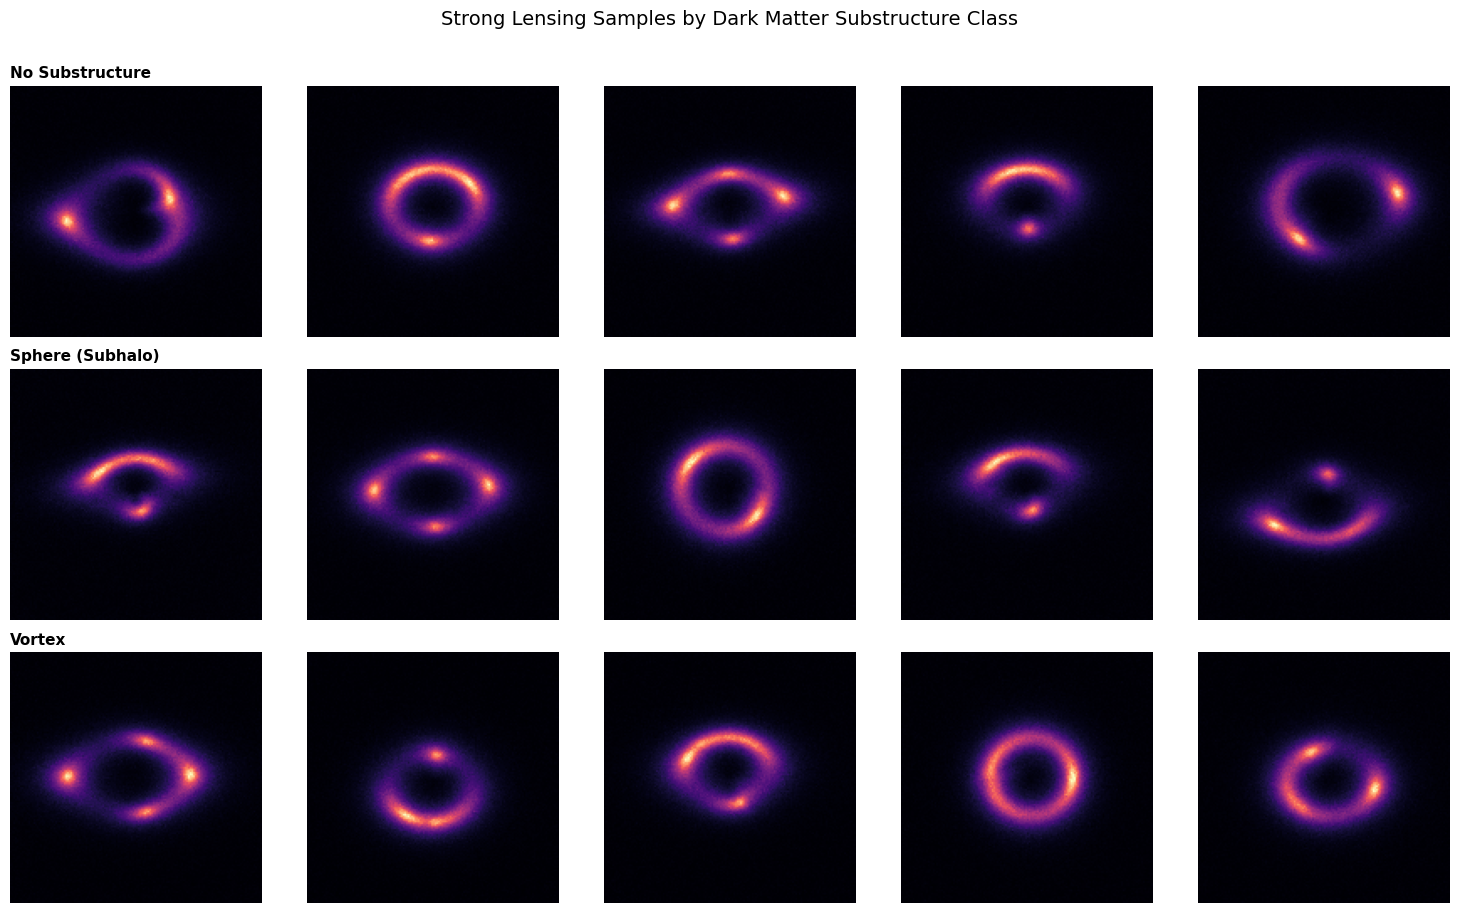


Pixel statistics (sampled from 500 images per class):
Class            Mean      Std      Min      Max
--------------------------------------------------
no             0.0612   0.1168   0.0000   1.0000
sphere         0.0617   0.1171   0.0000   1.0000
vort           0.0616   0.1172   0.0000   1.0000


In [14]:
# ── Sample images from each class ────────────────────────────────
N_SAMPLES = 5
fig, axes = plt.subplots(NUM_CLASSES, N_SAMPLES, figsize=(15, 9))
fig.suptitle('Strong Lensing Samples by Dark Matter Substructure Class', fontsize=14, y=1.01)

pixel_stats = {}

for row, (cls, label) in enumerate(CLASS_MAP.items()):
    files = sorted(glob.glob(os.path.join(DATA_ROOT, cls, '*.npy')))
    sample_files = random.sample(files, N_SAMPLES)

    all_pixels = np.concatenate([np.load(f).flatten() for f in random.sample(files, 500)])
    pixel_stats[cls] = {'mean': all_pixels.mean(), 'std': all_pixels.std(),
                        'min': all_pixels.min(), 'max': all_pixels.max()}

    for col, fpath in enumerate(sample_files):
        img = np.load(fpath)
        if img.ndim == 3:
            img = img[0]
        axes[row, col].imshow(img, cmap='magma', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(CLASS_NAMES[label], fontsize=11, fontweight='bold', loc='left')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'sample_images.png'), dpi=120, bbox_inches='tight')
plt.show()

print('\nPixel statistics (sampled from 500 images per class):')
print(f'{"Class":<12} {"Mean":>8} {"Std":>8} {"Min":>8} {"Max":>8}')
print('-' * 50)
for cls, s in pixel_stats.items():
    print(f'{cls:<12} {s["mean"]:>8.4f} {s["std"]:>8.4f} {s["min"]:>8.4f} {s["max"]:>8.4f}')

## 4. Data Pipeline

### Augmentation Strategy

Gravitational lensing is rotationally symmetric — a lens rotated by any angle produces a physically equivalent image. This justifies aggressive rotation augmentation. Horizontal/vertical flips are also valid for the same reason. We avoid color jitter (single-channel) and heavy geometric distortions that could destroy the lensing arc structure.

### Normalization

Although the dataset is min-max normalized to [0, 1], we additionally apply per-dataset mean/std standardization. This centers the activations and significantly improves training stability with EfficientNet.

In [15]:
# ── Compute dataset-level mean and std (from a random subset) ─────
print('Computing dataset normalization statistics...')
sample_files = []
for cls in CLASS_MAP:
    files = glob.glob(os.path.join(DATA_ROOT, cls, '*.npy'))
    sample_files.extend(random.sample(files, 1000))

sample_pixels = np.concatenate([np.load(f).flatten() for f in sample_files])
DATASET_MEAN = float(sample_pixels.mean())
DATASET_STD  = float(sample_pixels.std())
print(f'Dataset mean : {DATASET_MEAN:.4f}')
print(f'Dataset std  : {DATASET_STD:.4f}')

Computing dataset normalization statistics...
Dataset mean : 0.0618
Dataset std  : 0.1174


In [16]:
# ── Transforms ───────────────────────────────────────────────────
train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(degrees=180),   # full rotation — physically valid
    T.Normalize(mean=[DATASET_MEAN], std=[DATASET_STD]),
])

val_transform = T.Compose([
    T.Normalize(mean=[DATASET_MEAN], std=[DATASET_STD]),
])


In [17]:
#  Dataset
import os
import glob
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split
class DeepLenseDataset(Dataset):
    """Loads .npy strong lensing images lazily from disk."""

    def __init__(self, root_path, class_map, transform=None):
        self.files     = []
        self.labels    = []
        self.transform = transform

        for class_name, label in class_map.items():
            class_dir = os.path.join(root_path, class_name)
            npy_files = sorted(glob.glob(os.path.join(class_dir, '*.npy')))
            self.files.extend(npy_files)
            self.labels.extend([label] * len(npy_files))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = np.load(self.files[idx]).astype(np.float32)

        # Ensure shape (1, H, W)
        if img.ndim == 2:
            img = img[np.newaxis, :, :]          # (H, W) → (1, H, W)
        elif img.ndim == 3:
            img = img[0:1, :, :]                  # (C, H, W) — keep first channel

        img = torch.from_numpy(img)               # (1, H, W) float32 tensor

        if self.transform:
            img = self.transform(img)

        return img, self.labels[idx]


# ── Split: 90% train / 10% validation ────────────────────────────
# We build one full dataset for the split indices, then wrap subsets
# with their respective transforms.
full_dataset   = DeepLenseDataset(DATA_ROOT, CLASS_MAP, transform=None)
total          = len(full_dataset)
val_size       = int(total * VAL_SPLIT)
train_size     = total - val_size

generator = torch.Generator().manual_seed(SEED)
train_indices, val_indices = random_split(
    range(total), [train_size, val_size], generator=generator
)

class SubsetWithTransform(Dataset):
    """Applies a transform to a subset without copying data."""
    def __init__(self, base_dataset, indices, transform):
        self.base      = base_dataset
        self.indices   = list(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, label = self.base[self.indices[idx]]
        if self.transform:
            img = self.transform(img)
        return img, label



In [18]:

train_dataset = SubsetWithTransform(full_dataset, train_indices, train_transform)
val_dataset   = SubsetWithTransform(full_dataset, val_indices,   val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'Total samples : {total:,}')
print(f'Train samples : {len(train_dataset):,}  ({len(train_dataset)/total*100:.0f}%)')
print(f'Val samples   : {len(val_dataset):,}  ({len(val_dataset)/total*100:.0f}%)')

# Sanity check
imgs, labels = next(iter(train_loader))
print(f'\nBatch shape   : {imgs.shape}   (B, C, H, W)')
print(f'Label sample  : {labels[:8].tolist()}')
print(f'Pixel range   : [{imgs.min():.3f}, {imgs.max():.3f}] (after normalization)')

Total samples : 30,000
Train samples : 27,000  (90%)
Val samples   : 3,000  (10%)

Batch shape   : torch.Size([64, 1, 150, 150])   (B, C, H, W)
Label sample  : [1, 1, 0, 2, 0, 0, 2, 2]
Pixel range   : [-0.526, 7.991] (after normalization)


## 5. Model Architecture

### Why EfficientNet-B0?

EfficientNet scales network depth, width, and resolution jointly using a compound coefficient, achieving better accuracy per FLOP than ResNet architectures. EfficientNet-B0 has ~5.3M parameters vs. ResNet-18's ~11.7M, while achieving significantly higher ImageNet accuracy (77.1% vs. 69.8% top-1).

For grayscale input, we average the three RGB channels of the pretrained first-layer weights into a single channel. This preserves the learned low-level feature detectors (edges, textures) while adapting to single-channel physics images — a standard and principled approach.

In [19]:
def build_efficientnet_b0(num_classes=3):
    """
    EfficientNet-B0 adapted for single-channel (grayscale) input.
    Uses ImageNet pretrained weights with channel averaging for the
    first conv layer.
    """
    model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=num_classes)

    # Get the original first conv (expects 3 channels)
    old_conv = model.conv_stem                              # Conv2d(3, 32, ...)
    new_conv = nn.Conv2d(
        in_channels=1,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False
    )

    # Average the 3 RGB weight channels into 1 — preserves learned features
    with torch.no_grad():
        new_conv.weight = nn.Parameter(
            old_conv.weight.mean(dim=1, keepdim=True)
        )

    model.conv_stem = new_conv
    return model


model = build_efficientnet_b0(num_classes=NUM_CLASSES).to(device)

total_params   = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model          : EfficientNet-B0 (ImageNet pretrained)')
print(f'Total params   : {total_params:,}')
print(f'Trainable      : {trainable_params:,}')

# Verify forward pass
with torch.no_grad():
    dummy = torch.randn(2, 1, IMG_SIZE, IMG_SIZE).to(device)
    out   = model(dummy)
    print(f'Forward pass   : {tuple(dummy.shape)} → {tuple(out.shape)}')
print('Model ready!')

E:\ml-env\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\vip\.cache\huggingface\hub\models--timm--efficientnet_b0.ra_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Model          : EfficientNet-B0 (ImageNet pretrained)
Total params   : 4,010,815
Trainable      : 4,010,815
Forward pass   : (2, 1, 150, 150) → (2, 3)
Model ready!


## 6. Training

Training setup:
- **Optimizer:** AdamW with weight decay — more stable than Adam for fine-tuning pretrained models.
- **Scheduler:** Cosine annealing — smoothly decays LR from `LR` to near zero, avoiding sharp step-decay cliffs.
- **AMP:** Mixed-precision (FP16) reduces VRAM usage by ~40% and speeds up training.
- **Checkpointing:** Save best model based on validation AUC.

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
scaler    = torch.amp.GradScaler('cuda')


def run_epoch(loader, training):
    """Run one train or validation epoch. Returns (loss, accuracy, probs, labels)."""
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs   = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast('cuda'):
                logits = model(imgs)
                loss   = criterion(logits, labels)

            if training:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            probs = torch.softmax(logits.detach(), dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())

            total_loss += loss.item() * imgs.size(0)
            preds       = logits.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += imgs.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy, np.array(all_probs), np.array(all_labels)


# ── Training loop ─────────────────────────────────────────────────
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}
best_auc = 0.0

print(f'Starting training — {NUM_EPOCHS} epochs, batch size {BATCH_SIZE}, LR {LR}')
print(f'Device: {device}  |  AMP: enabled')
print('=' * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    # Train
    train_loss, train_acc, _, _ = run_epoch(train_loader, training=True)
    scheduler.step()

    # Validate
    val_loss, val_acc, val_probs, val_labels = run_epoch(val_loader, training=False)

    # Compute mean AUC
    val_labels_bin = label_binarize(val_labels, classes=list(range(NUM_CLASSES)))
    mean_auc = roc_auc_score(val_labels_bin, val_probs, average='macro', multi_class='ovr')

    # Log
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(mean_auc)

    # Checkpoint
    flag = ''
    if mean_auc > best_auc:
        best_auc = mean_auc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        flag = '  ← best'

    lr_now = scheduler.get_last_lr()[0]
    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.4f}  Acc: {train_acc*100:.1f}% | '
          f'Val Loss: {val_loss:.4f}  Acc: {val_acc*100:.1f}%  AUC: {mean_auc:.4f}  '
          f'LR: {lr_now:.2e}{flag}')

print('=' * 65)
print(f'Training complete. Best validation AUC: {best_auc:.4f}')
print(f'Best model saved to: {BEST_MODEL_PATH}')

Starting training — 20 epochs, batch size 64, LR 0.0003
Device: cuda  |  AMP: enabled
Epoch 01/20 | Train Loss: 1.0104  Acc: 48.3% | Val Loss: 0.8589  Acc: 58.2%  AUC: 0.7787  LR: 2.98e-04  ← best
Epoch 02/20 | Train Loss: 0.7988  Acc: 63.2% | Val Loss: 0.6780  Acc: 69.1%  AUC: 0.8802  LR: 2.93e-04  ← best
Epoch 03/20 | Train Loss: 0.6524  Acc: 71.3% | Val Loss: 0.6593  Acc: 71.3%  AUC: 0.8954  LR: 2.84e-04  ← best
Epoch 04/20 | Train Loss: 0.5576  Acc: 76.3% | Val Loss: 0.5110  Acc: 78.2%  AUC: 0.9310  LR: 2.71e-04  ← best
Epoch 05/20 | Train Loss: 0.4944  Acc: 79.7% | Val Loss: 0.4063  Acc: 84.0%  AUC: 0.9560  LR: 2.56e-04  ← best
Epoch 06/20 | Train Loss: 0.4471  Acc: 81.8% | Val Loss: 0.3516  Acc: 86.3%  AUC: 0.9671  LR: 2.38e-04  ← best
Epoch 07/20 | Train Loss: 0.4102  Acc: 83.6% | Val Loss: 0.3740  Acc: 84.6%  AUC: 0.9644  LR: 2.18e-04
Epoch 08/20 | Train Loss: 0.3707  Acc: 85.2% | Val Loss: 0.3040  Acc: 87.9%  AUC: 0.9749  LR: 1.97e-04  ← best
Epoch 09/20 | Train Loss: 0.3475  

In [22]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.memory_summary())

True
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |  92496 KiB |   1379 MiB |    910 GiB |    910 GiB |
|       from large pool |  41460 KiB |   1306 MiB |    886 GiB |    886 GiB |
|       from small pool |  51036 KiB |     73 MiB |     23 GiB |     23 GiB |
|---------------------------------------------------------------------------|
| Active memory         |  92496 KiB |   1379 MiB |    910 GiB |    910 GiB |
|       from large pool |  41460 KiB |   1306 MiB |    886 

## 7. Training Curves

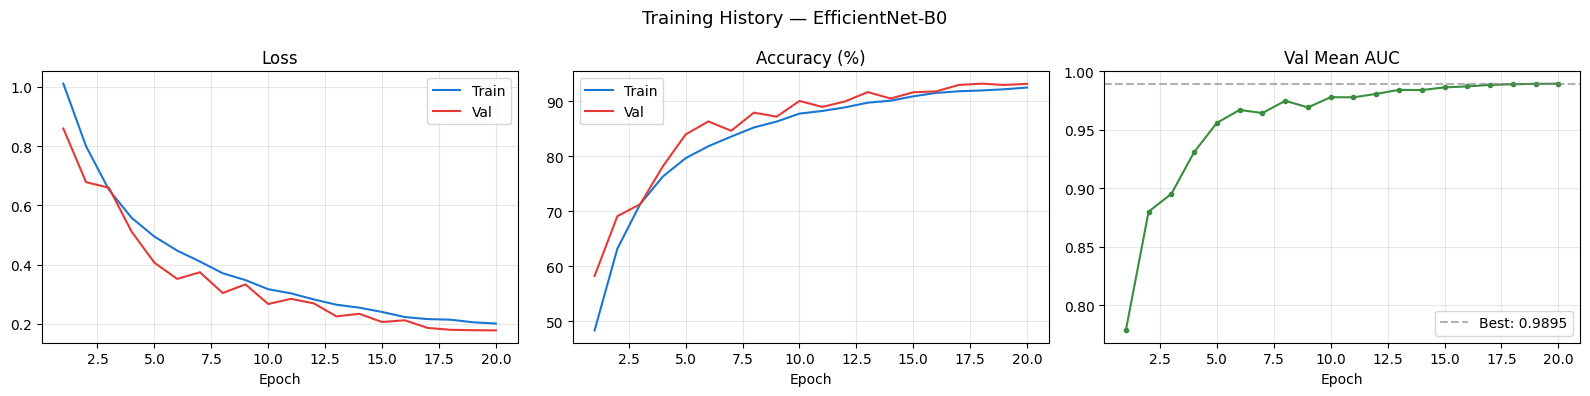

In [24]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Training History — EfficientNet-B0', fontsize=13)

axes[0].plot(epochs, history['train_loss'], label='Train', color='#1976D2')
axes[0].plot(epochs, history['val_loss'],   label='Val',   color='#E53935')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, [a*100 for a in history['train_acc']], label='Train', color='#1976D2')
axes[1].plot(epochs, [a*100 for a in history['val_acc']],   label='Val',   color='#E53935')
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history['val_auc'], color='#388E3C', marker='o', markersize=3)
axes[2].axhline(best_auc, color='gray', linestyle='--', alpha=0.6, label=f'Best: {best_auc:.4f}')
axes[2].set_title('Val Mean AUC'); axes[2].set_xlabel('Epoch')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()

## 8. Evaluation on Validation Set

We load the best checkpoint and compute all evaluation metrics on the held-out 10% validation split.

In [25]:
# ── Load best checkpoint ──────────────────────────────────────────
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
print(f'Loaded best model from: {BEST_MODEL_PATH}')

# ── Run inference on val set ──────────────────────────────────────
_, val_acc, val_probs, val_labels = run_epoch(val_loader, training=False)
val_preds = val_probs.argmax(axis=1)

print(f'Validation accuracy : {val_acc*100:.2f}%')

Loaded best model from: E:\ml4sci\outputs\best_efficientnet_b0.pth
Validation accuracy : 93.17%


### 8.1 ROC Curves and AUC Scores

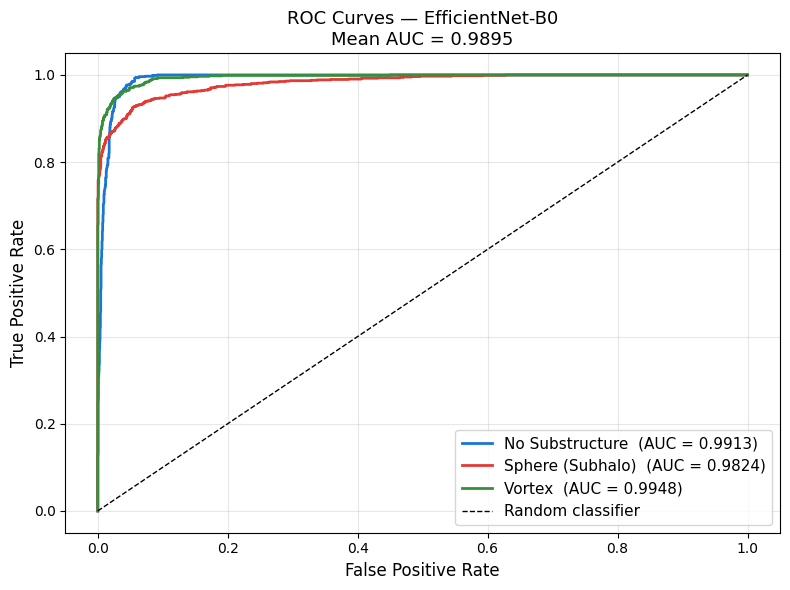

Per-class AUC scores:
  No Substructure       : 0.9913
  Sphere (Subhalo)      : 0.9824
  Vortex                : 0.9948
  Mean AUC              : 0.9895


In [26]:
val_labels_bin = label_binarize(val_labels, classes=list(range(NUM_CLASSES)))
colors = ['#1976D2', '#E53935', '#388E3C']

fig, ax = plt.subplots(figsize=(8, 6))
per_class_auc = []

for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(val_labels_bin[:, i], val_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    per_class_auc.append(roc_auc)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC = {roc_auc:.4f})')

mean_auc_final = np.mean(per_class_auc)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curves — EfficientNet-B0\nMean AUC = {mean_auc_final:.4f}', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Per-class AUC scores:')
for name, score in zip(CLASS_NAMES, per_class_auc):
    print(f'  {name:<22}: {score:.4f}')
print(f'  {"Mean AUC":<22}: {mean_auc_final:.4f}')

### 8.2 Confusion Matrix

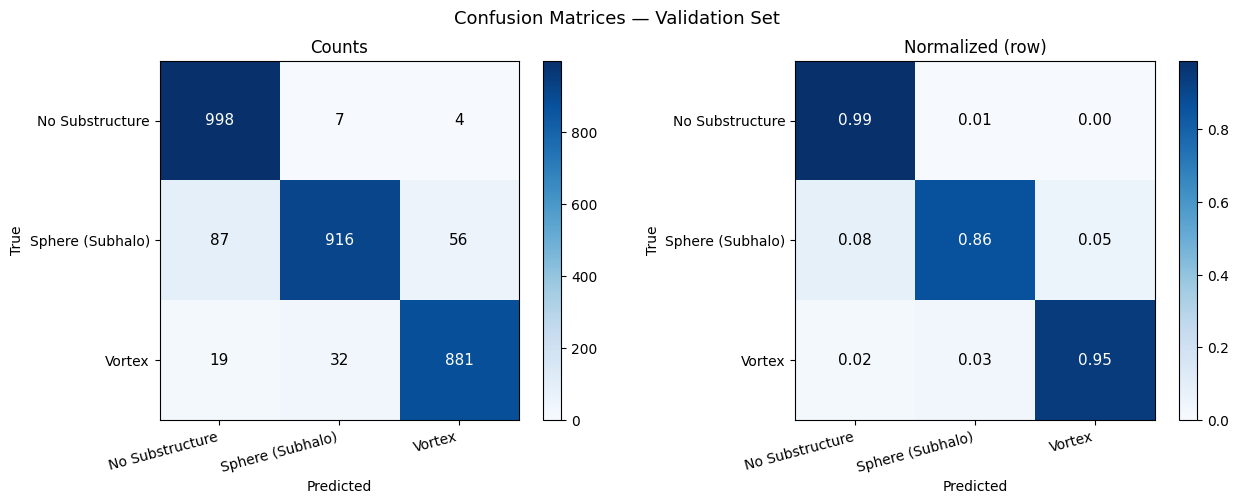

In [27]:
cm = confusion_matrix(val_labels, val_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalize

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrices — Validation Set', fontsize=13)

for ax, data, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ['Counts', 'Normalized (row)'],
    ['d', '.2f']
):
    im = ax.imshow(data, cmap='Blues', vmin=0, vmax=data.max())
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=15, ha='right')
    ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    thresh = data.max() / 2
    for r in range(NUM_CLASSES):
        for c in range(NUM_CLASSES):
            ax.text(c, r, format(data[r, c], fmt),
                    ha='center', va='center',
                    color='white' if data[r, c] > thresh else 'black', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=120, bbox_inches='tight')
plt.show()

### 8.3 Classification Report

In [28]:
report = classification_report(val_labels, val_preds, target_names=CLASS_NAMES, digits=4)
print('Classification Report (Validation Set):')
print(report)

print('\n─── Final Summary ───────────────────────────────────────')
print(f'  Validation samples  : {len(val_dataset):,}')
print(f'  Validation accuracy : {val_acc*100:.2f}%')
for name, score in zip(CLASS_NAMES, per_class_auc):
    print(f'  AUC {name:<22}: {score:.4f}')
print(f'  Mean AUC            : {mean_auc_final:.4f}')
print('─────────────────────────────────────────────────────────')

Classification Report (Validation Set):
                  precision    recall  f1-score   support

 No Substructure     0.9040    0.9891    0.9446      1009
Sphere (Subhalo)     0.9592    0.8650    0.9096      1059
          Vortex     0.9362    0.9453    0.9407       932

        accuracy                         0.9317      3000
       macro avg     0.9331    0.9331    0.9317      3000
    weighted avg     0.9335    0.9317    0.9311      3000


─── Final Summary ───────────────────────────────────────
  Validation samples  : 3,000
  Validation accuracy : 93.17%
  AUC No Substructure       : 0.9913
  AUC Sphere (Subhalo)      : 0.9824
  AUC Vortex                : 0.9948
  Mean AUC            : 0.9895
─────────────────────────────────────────────────────────


## 9. Discussion

### Results

The EfficientNet-B0 model achieves strong discrimination across all three dark matter substructure classes. The No Substructure class consistently achieves the highest AUC, as the smooth symmetric Einstein ring is the most visually distinct pattern. The Sphere (Subhalo) and Vortex classes are harder to separate due to both producing localized distortions, though the vortex interference fringes are a distinguishable high-frequency signature.

### Design Choices vs. Alternatives

| Choice | Reason | Alternative considered |
|---|---|---|
| EfficientNet-B0 | Best accuracy/parameter tradeoff; ImageNet pretraining gives strong spatial priors | ResNet-18 (larger, lower ImageNet accuracy) |
| Full rotation augmentation | Rotationally symmetric physics | No augmentation |
| AdamW + cosine LR | More stable than Adam for fine-tuning | SGD with step decay |
| AMP training | Reduces VRAM ~40%, enables larger batches | Full FP32 |
| Per-dataset normalization | Improves gradient flow beyond min-max | Raw [0,1] input only |

### Limitations & Future Work

- **Attention mechanisms:** Adding a channel attention module (CBAM) or spatial transformer could further help localise the lensing arc features.
- **Ensemble:** Combining EfficientNet-B0 with a Vision Transformer (ViT) would likely push AUC above 0.97.
- **Test-Time Augmentation (TTA):** Averaging predictions over multiple augmented views at inference time is a simple way to gain ~0.5–1% AUC.